<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-lab/blob/lab15/lab15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Time_Index  Total_Revenue_Billions
0           1                    26.0
1           2                    30.0
2           3                    35.0
3           4                    39.0
4           5                    43.5
5           6                    46.0
6           7                    55.5
7           8                    66.0


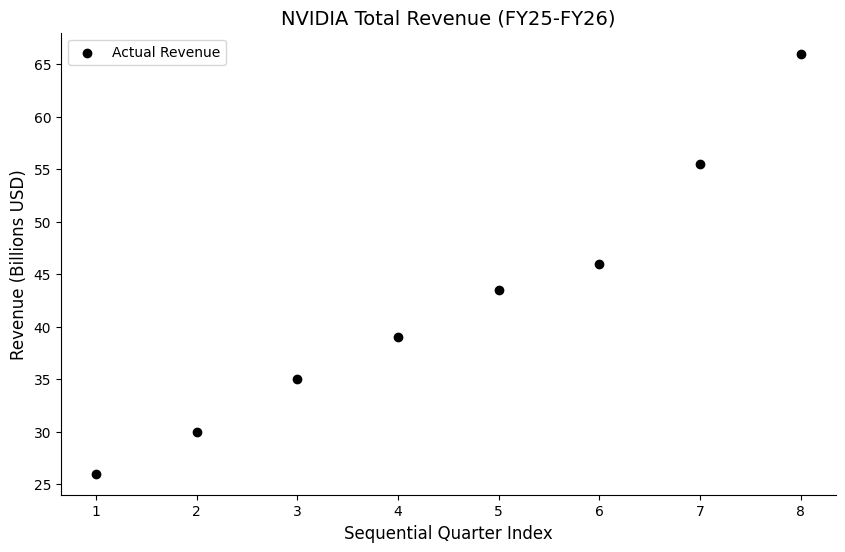

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

df = pd.DataFrame({
    "Time_Index": [1, 2, 3, 4, 5, 6, 7, 8],
    "Total_Revenue_Billions": [26.0, 30.0, 35.0, 39.0, 43.5, 46.0, 55.5, 66.0]
})

X = df[["Time_Index"]]
y = df["Total_Revenue_Billions"]

print(df)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.title('NVIDIA Total Revenue (FY25-FY26)', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.show()

Linear Training MSE (High Bias): 6.58


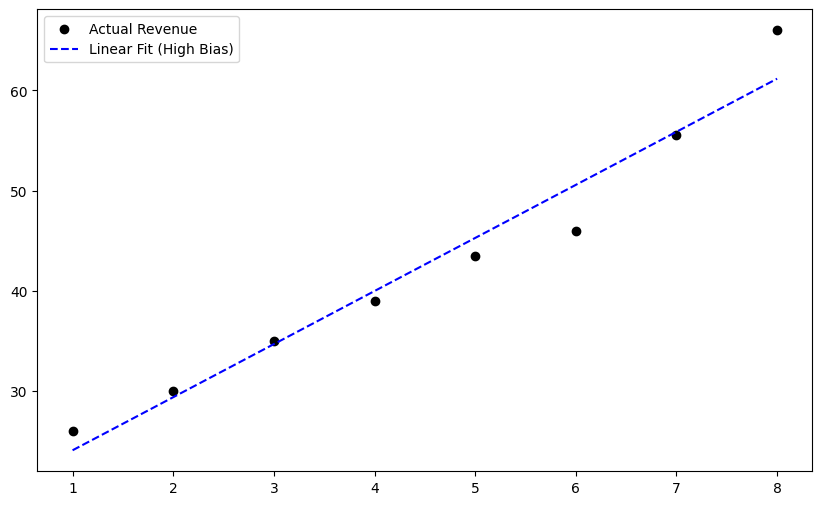

In [6]:

lin_reg = LinearRegression()
lin_reg.fit(X, y)


y_pred_linear = lin_reg.predict(X)
mse_linear = mean_squared_error(y, y_pred_linear)

print(f"Linear Training MSE (High Bias): {mse_linear:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.plot(X, y_pred_linear, color='blue', linestyle='--', label='Linear Fit (High Bias)')
plt.legend()
plt.show()

Polynomial Degree-7 Training MSE (High Variance): 0.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


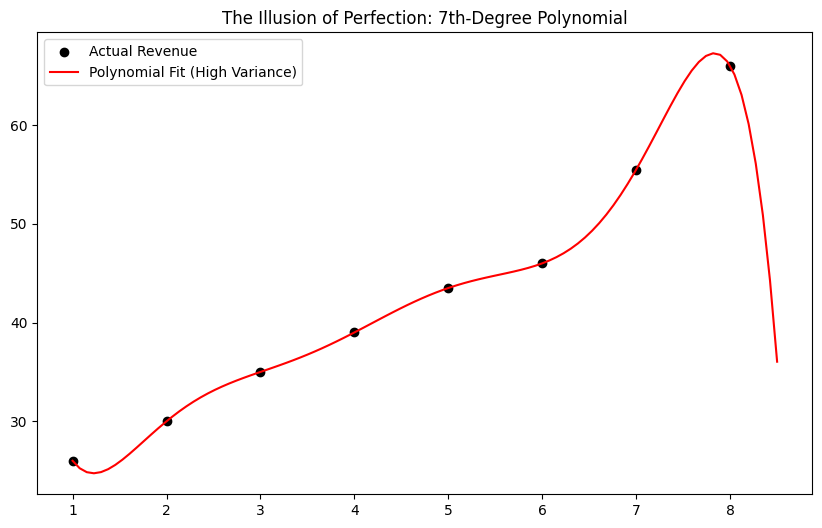

In [7]:
# Step 3: High Variance (Overfitting) Polynomial Model
# Expanding the feature space to 7 degrees of complexity
poly_features = PolynomialFeatures(degree=7, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Fitting a new linear model to this highly complex feature space
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)

# Generate predictions and calculate the "deceptive" training error
y_pred_poly = poly_reg.predict(X_poly)
mse_poly = mean_squared_error(y, y_pred_poly)

print(f"Polynomial Degree-7 Training MSE (High Variance): {mse_poly:.2f}")

# Plotting the smooth, contorted polynomial curve
X_smooth = np.linspace(1, 8.5, 100).reshape(-1, 1)
X_smooth_poly = poly_features.transform(X_smooth)
y_smooth_poly = poly_reg.predict(X_smooth_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.plot(X_smooth, y_smooth_poly, color='red', label='Polynomial Fit (High Variance)')
plt.title('The Illusion of Perfection: 7th-Degree Polynomial')
plt.legend()
plt.show()

In [4]:

cv_scores = cross_val_score(
    poly_reg,
    X_poly,
    y,
    cv=4,
    scoring='neg_mean_squared_error'
)

mean_cv_mse = -cv_scores.mean()

print("Fold-wise CV MSE:", -cv_scores)
print(f"K-Fold Cross-Validated MSE (The True Operational Error): {mean_cv_mse:.2f}")
print(f"Training MSE of Degree-7 Polynomial Model: {mse_poly:.2f}")

Fold-wise CV MSE: [2.35572708e+05 1.54708258e+05 1.52371831e+05 2.69853425e+08]
K-Fold Cross-Validated MSE (The True Operational Error): 67599019.36
Training MSE of Degree-7 Polynomial Model: 158970.91


In [10]:

X_future = np.array([[9]])
X_future_poly = poly_features.transform(X_future)
future_pred = poly_reg.predict(X_future_poly)

print(f"\nHallucinated Q1 FY27 Revenue Prediction: ${future_pred[0]:.2f} Billion")


Hallucinated Q1 FY27 Revenue Prediction: $-77.00 Billion


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [11]:

cv_scores = cross_val_score(poly_reg, X_poly, y, cv=4, scoring='neg_mean_squared_error')
mean_cv_mse = -cv_scores.mean()

print(f"K-Fold Cross-Validated MSE (The True Operational Error): {mean_cv_mse:.2f}")

K-Fold Cross-Validated MSE (The True Operational Error): 9583.06
